In [2]:
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
# import pwlf

import functools

import brian2 as br2
from brian2.units import volt, amp, metre, second
from brian2.units import mV, uA, cm, ms, uF, mS, Hz
print(f"{br2.__version__ = }")

br2.__version__ = '2.7.0'


# 复现 HH 检测失败的现象

In [3]:
@br2.implementation('numpy', discard_units=True)
@br2.check_units(v=volt, result=Hz)
def alpha_m(v):
    x = v / mV
    a = 0.1 * (x + 40.0) / (1 - np.exp(-0.1 * (x + 40.0)))
    return a / ms

@br2.implementation('numpy', discard_units=True)
@br2.check_units(v=volt, result=Hz)
def alpha_n(v):
    x = v / mV
    a = 0.01 * (x + 55.0) / (1 - np.exp(-0.1 * (x + 55.0)))
    return a / ms

@br2.implementation('numpy', discard_units=True)
@br2.check_units(v=volt, result=Hz)
def alpha_h(v):
    x = v / mV
    a = 0.07 * np.exp(-(x + 65.0) / 20.0)
    return a / ms

@br2.implementation('numpy', discard_units=True)
@br2.check_units(v=volt, result=Hz)
def beta_m(v):
    x = v / mV
    b = 4.0 * np.exp(-(x + 65.0) / 18.0)
    return b / ms

@br2.implementation('numpy', discard_units=True)
@br2.check_units(v=volt, result=Hz)
def beta_n(v):
    x = v / mV
    b = 0.125 * np.exp(-(x + 65.0) / 80.0)
    return b / ms

@br2.implementation('numpy', discard_units=True)
@br2.check_units(v=volt, result=Hz)
def beta_h(v):
    x = v / mV
    b = 1.0 / (1.0 + np.exp(-0.1 * (x + 35)))
    return b / ms

In [4]:
def hh00():
    # 模型的方程
    equations = '''
        # 膜电位
        dv/dt  = (- I_Na - I_K - I_L + I_ext + I_syn) / C_m : volt
        I_Na   = g_Na * m**3 * h * (v - E_Na) : amp*metre**-2
        I_K    = g_K  * n**4     * (v - E_K)  : amp*metre**-2
        I_L    = g_L             * (v - E_L)  : amp*metre**-2
    
        # 门控变量
        dm/dt = alpha_m(v) * (1 - m) - beta_m(v) * m : 1
        dn/dt = alpha_n(v) * (1 - n) - beta_n(v) * n : 1
        dh/dt = alpha_h(v) * (1 - h) - beta_h(v) * h : 1
        
        # 外界电流（无效，实际更新在 v 上）
        # 即: I_ext = sum(poisson_weight * delta(t - t_poisson))
        I_ext                                 : amp*metre**-2
        
        # 突触电流（无效，实际更新在 v 上）
        # 即: I_syn = sum(synapse_weight * delta(t - t_spike))
        I_syn                                 : amp*metre**-2
    '''

    # 膜电位方程的参数
    parameters = {
        'C_m': 1.0 * uF/cm**2,
        'g_L': 0.3 * mS/cm**2,
        'E_L': -54.4 * mV,
        'g_Na': 120.0 * mS/cm**2,
        'E_Na': 50.0 * mV,
        'g_K': 36.0 * mS/cm**2,
        'E_K': -77.0 * mV,
    }

    # 静息态与放电阈值
    V_rest, V_thres = [-65.0, -20.0] * mV

    # 神经元的个数、稀疏度和平均入度
    N = 100
    p = 0.1
    K = p * N

    # 不同阶段的外界电流和突触电流的参数
    np.random.seed(601)
    W_1 = (np.random.rand(N, N) < p).astype(float)
    W_2 = (np.random.rand(N, N) < p).astype(float)
    stages = [
        # 第一阶段
        {
            'duration': 50.0 * ms,
            'poisson_rate': 3.0 * K / ms,
            'poisson_weight': 2.0 / np.sqrt(K) * (uA / cm**2 * ms),
            'synapse_weight': -10.0 / np.sqrt(K) * W_1 * (uA / cm**2 * ms),
        },
        # 第二阶段
        {
            'duration': 50.0 * ms,
            'poisson_rate': 3.0 * K / ms,
            'poisson_weight': 2.0 / np.sqrt(K) * (uA / cm**2 * ms),
            'synapse_weight': -10.0 / np.sqrt(K) * W_1 * (uA / cm**2 * ms),
        },
        # 第三阶段
        {
            'duration': 50.0 * ms,
            'poisson_rate': 3.0 * K / ms,
            'poisson_weight': 2.0 / np.sqrt(K) * (uA / cm**2 * ms),
            'synapse_weight': -10.0 / np.sqrt(K) * W_2 * (uA / cm**2 * ms),
        },
    ]
    
    # 预处理：找出所有可能相连的边（任一阶段相连即可）
    # 如果找不到，说明每个阶段都是零矩阵，为了简化代码，人为设置 0->0 相连
    # 请注意，这仍然可能导致性能低下，即使每个阶段稀疏连接。
    # 更优化更优雅的方案留待后续探究。
    mat = ((stage["synapse_weight"] != 0) for stage in stages)
    mat = functools.reduce(lambda x, y: x | y, mat)
    row, col = np.nonzero(mat)
    if row.size == 0:
        row, col = [0], [0]
        
    # 使用 brian2 演化模型
    br2.start_scope()
    br2.defaultclock.dt = 0.01 * ms
    
    # 定义神经元群体
    G = br2.NeuronGroup(
        N=N,
        model=equations,
        namespace=parameters,
        threshold="v > V_thres",
        refractory="v > V_thres",
        method='exponential_euler',
    )
    
    v0 =  V_rest + np.random.rand(N) * 5.0 * mV
    G.v[:] = v0
    G.m[:] = alpha_m(v0) / (alpha_m(v0) + beta_m(v0))
    G.n[:] = alpha_n(v0) / (alpha_n(v0) + beta_n(v0))
    G.h[:] = alpha_h(v0) / (alpha_h(v0) + beta_h(v0))
    
    # 定义泊松电流模型（但连接强度在后面模拟时才指定）
    PG = br2.PoissonGroup(N=N, rates=np.zeros(N) / ms)
    PS = br2.Synapses(
        PG, G,
        model='weight : amp*metre**-2*second',
        on_pre='v += weight / C_m',
        namespace=parameters,
    )
    PS.connect(j='i')
    
    # 定义突触电流模型（但连接在后面模拟时才指定）
    WS = br2.Synapses(
        G, G,
        model='weight : amp*metre**-2*second',
        on_pre='v += weight / C_m',
        namespace=parameters,
    )
    WS.connect(i=row, j=col)
    
    # 定义状态记录器（每一步迭代都要进行记录）
    Mc = br2.StateMonitor(G, ['v', ], record=True)
    Md = br2.SpikeMonitor(G)
    Mr = br2.PopulationRateMonitor(G)
    
    # 开始每个阶段的模拟
    for stage in stages:
        # 调整参数
        PG.rates = stage['poisson_rate']
        PS.weight = stage['poisson_weight']
        WS.weight[:] = stage['synapse_weight'][row, col]
        # 进行模拟
        br2.run(stage['duration'], report='text')
        
    return Mc, Md, Mr, W_1, W_2

In [5]:
Mc, Md, Mr, W_1, W_2 = hh00()

Starting simulation at t=0. s for a duration of 50. ms
27.57 ms (55%) simulated in 10s, estimated 8s remaining.
50. ms (100%) simulated in 18s
Starting simulation at t=50. ms for a duration of 50. ms
27.52 ms (55%) simulated in 10s, estimated 8s remaining.
50. ms (100%) simulated in 18s
Starting simulation at t=100. ms for a duration of 50. ms
27.53 ms (55%) simulated in 10s, estimated 8s remaining.
50. ms (100%) simulated in 18s


INFO       width adjusted from 10. ms to 9.99 ms [brian2.monitors.ratemonitor.adjusted_width]


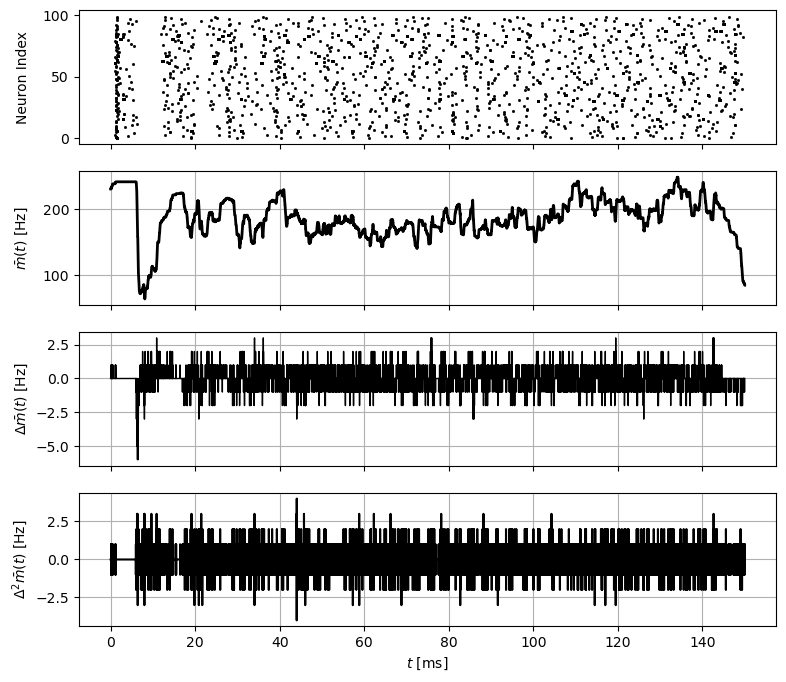

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(9, 8), sharex=True)

Z_SR = Mr.smooth_rate('flat', 10.0 * ms) / Hz

ax = axes[0]
ax.plot(Md.t / ms, Md.i, 'sk', ms=1)
ax.set_ylabel("Neuron Index")

ax = axes[1]
ax.plot(Mr.t / ms, Z_SR, c='k', lw=2)
ax.set_ylabel(r"$\bar{m}(t)$ [Hz]")
ax.grid()

ax = axes[2]
ax.plot(Mr.t[:-1] / ms, np.diff(Z_SR), c='k', lw=1)
ax.set_ylabel(r"$\Delta\bar{m}(t)$ [Hz]")
ax.grid()

ax = axes[3]
ax.plot(Mr.t[:-2] / ms, np.diff(Z_SR, 2), c='k')
ax.set_ylabel(r"$\Delta^2\bar{m}(t)$ [Hz]")
ax.grid()

axes[-1].set_xlabel("$t$ [ms]")
fig.align_ylabels(axes)
plt.show()

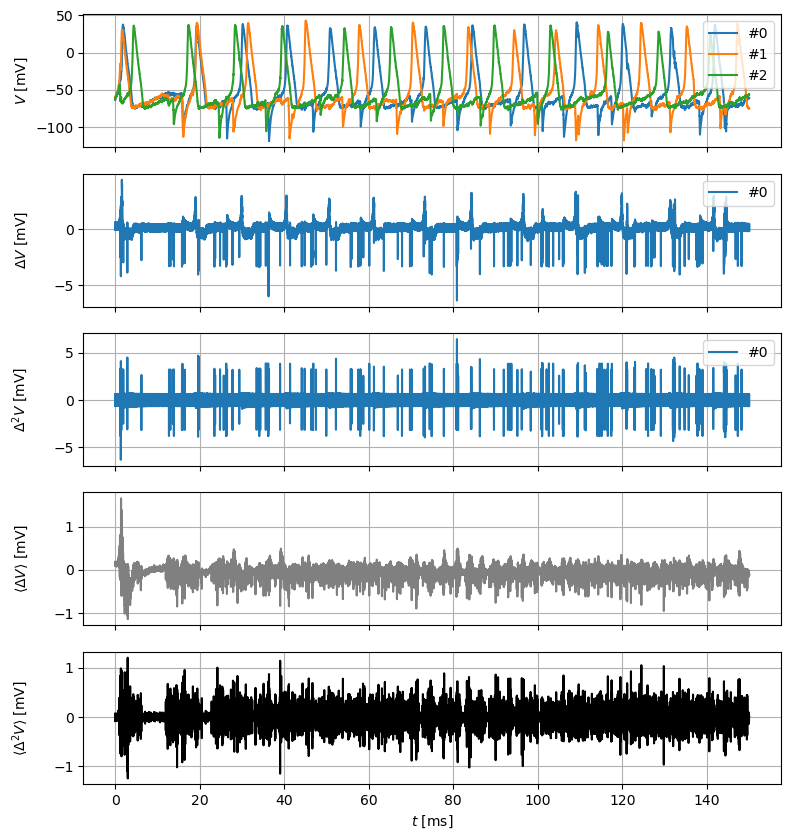

In [7]:
fig, axes = plt.subplots(5, 1, figsize=(9, 10), sharex=True)

ax = axes[0]
ax.plot(Mc.t / ms, Mc.v[0] / mV, c='C0', label='#0')
ax.plot(Mc.t / ms, Mc.v[1] / mV, c='C1', label='#1')
ax.plot(Mc.t / ms, Mc.v[2] / mV, c='C2', label='#2')
ax.set_ylabel("$V$ [mV]")
ax.grid()
ax.legend(loc='upper right')

ax = axes[1]
ax.plot(Mc.t[:-1] / ms, np.diff(Mc.v[0] / mV), c='C0', label='#0')
ax.set_ylabel(r"$\Delta V$ [mV]")
ax.grid()
ax.legend(loc='upper right')

ax = axes[2]
ax.plot(Mc.t[:-2] / ms, np.diff(Mc.v[0] / mV, 2), c='C0', label='#0')
ax.set_ylabel(r"$\Delta^2 V$ [mV]")
ax.grid()
ax.legend(loc='upper right')

ax = axes[3]
ax.plot(Mc.t[:-1] / ms, np.mean(np.diff(Mc.v / mV), axis=0), c='gray')
ax.set_ylabel(r"$\langle\Delta V\rangle$ [mV]")
ax.grid()

ax = axes[4]
ax.plot(Mc.t[:-2] / ms, np.diff(np.mean(Mc.v / mV, axis=0), 2), c='k')
ax.set_ylabel(r"$\langle\Delta^2 V\rangle$ [mV]")
ax.grid()

axes[-1].set_xlabel("$t$ [ms]")
fig.align_ylabels(axes)
plt.show()

In [8]:
from scipy.sparse.linalg import svds
DDV = np.diff(Mc.v / mV, 2, axis=1)
U, S, VT = svds(DDV[:,13000:], k=1, which='SM')
print(U.shape)
a = U.flatten()

(100, 1)


In [9]:
S

array([15.9877434])

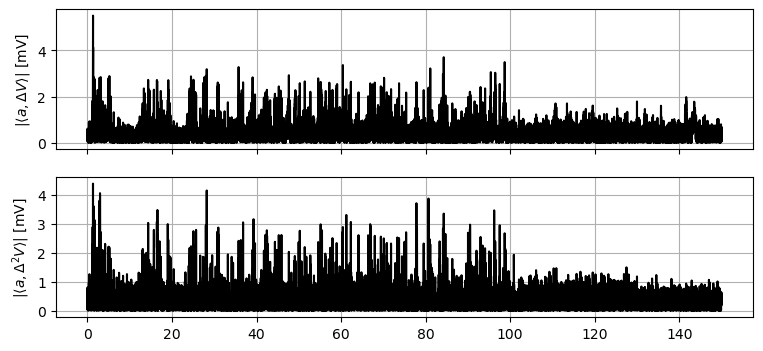

In [10]:
# E, EV = np.linalg.eig(W_1.T - W_2.T)
# idx = np.argmax(np.real(E))
# a = EV[:, idx]
# print(E[idx])

# E, EV = np.linalg.eig(W_2.T)
# idx = np.argmin(np.abs(E))
# a = EV[:, idx]
# print(E[idx])


fig, axes = plt.subplots(2, 1, figsize=(9, 4), sharex=True)

ax = axes[0]
ax.plot(Mc.t[:-1] / ms, np.abs(np.dot(a, np.diff(Mc.v / mV, 1))), c='k')
ax.set_ylabel(r"$|\langle a,\Delta V\rangle|$ [mV]")

ax.grid()

ax = axes[1]
ax.plot(Mc.t[:-2] / ms, np.abs(np.dot(a, np.diff(Mc.v / mV, 2))), c='k')
ax.set_ylabel(r"$|\langle a,\Delta^2 V\rangle|$ [mV]")
ax.grid()

plt.show()

# 换成 LIF 模型

In [118]:
def lifcc():
    # 神经元的个数、稀疏度和平均入度
    N = 1000
    p = 0.1
    K = p * N

    # 模型的方程
    equations = '''
        dv/dt = (I0 - v)/tau : 1
    '''

    # 膜电位方程的参数
    parameters = {
        'tau': 1.2 * ms,
        'I0': 0.2 * np.sqrt(K),
    }

    # 静息态与放电阈值
    V_rest, V_thres = 0.0, 1.0
    
    # 不同阶段的外界电流和突触电流的参数
    np.random.seed(123)
    W_1 = (np.random.rand(N, N) < p).astype(float)
    W_2 = (np.random.rand(N, N) < p).astype(float)
    stages = [
        # 第一阶段
        {
            'duration': 50.0 * ms,
            'synapse_weight': -1.0 / np.sqrt(K) * W_1,
        },
        # 第二阶段
        {
            'duration': 50.0 * ms,
            'synapse_weight': -1.0 / np.sqrt(K) * W_1,
        },
        # 第三阶段
        {
            'duration': 50.0 * ms,
            'synapse_weight': -1.0 / np.sqrt(K) * W_2,
        },
    ]
    
    # 预处理：找出所有可能相连的边（任一阶段相连即可）
    # 如果找不到，说明每个阶段都是零矩阵，为了简化代码，人为设置 0->0 相连
    # 请注意，这仍然可能导致性能低下，即使每个阶段稀疏连接。
    # 更优化更优雅的方案留待后续探究。
    mat = ((stage["synapse_weight"] != 0) for stage in stages)
    mat = functools.reduce(lambda x, y: x | y, mat)
    row, col = np.nonzero(mat)
    if row.size == 0:
        row, col = [0], [0]
        
    # 使用 brian2 演化模型
    br2.start_scope()
    br2.defaultclock.dt = 0.001 * ms
    
    G = br2.NeuronGroup(
        N=N,
        model=equations,
        namespace=parameters,
        threshold="v > V_thres",
        reset = "v = V_rest",
        method='exponential_euler',
    )
    G.v[:] = np.random.rand(N)
    
    # 定义突触电流模型（但连接在后面模拟时才指定）
    WS = br2.Synapses(
        G, G,
        model='weight : 1',
        on_pre='v += weight',
        namespace=parameters,
    )
    WS.connect(i=row, j=col)
    
    # 定义状态记录器（每一步迭代都要进行记录）
    Mc = br2.StateMonitor(G, ['v'], record=True)
    Md = br2.SpikeMonitor(G)
    Mr = br2.PopulationRateMonitor(G)

    # 开始每个阶段的模拟
    for stage in stages:
        # 调整参数
        WS.weight[:] = stage['synapse_weight'][row, col]
        # 进行模拟
        br2.run(stage['duration'], report='text')

        
    return Mc, Md, Mr, W_1, W_2

In [119]:
Mc, Md, Mr, W_1, W_2 = lifcc()

Starting simulation at t=0. s for a duration of 50. ms
50. ms (100%) simulated in 4s
Starting simulation at t=50. ms for a duration of 50. ms
50. ms (100%) simulated in 4s
Starting simulation at t=100. ms for a duration of 50. ms
50. ms (100%) simulated in 4s


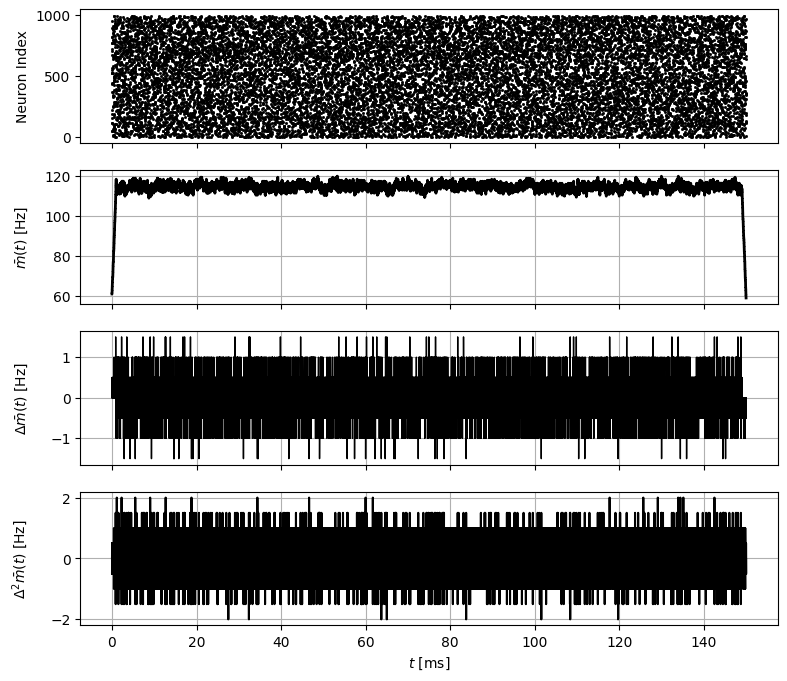

In [120]:
fig, axes = plt.subplots(4, 1, figsize=(9, 8), sharex=True)

Z_SR = Mr.smooth_rate('flat', 2.0 * ms) / Hz

ax = axes[0]
ax.plot(Md.t / ms, Md.i, 'sk', ms=1)
ax.set_ylabel("Neuron Index")

ax = axes[1]
ax.plot(Mr.t / ms, Z_SR, c='k', lw=2)
ax.set_ylabel(r"$\bar{m}(t)$ [Hz]")
ax.grid()

ax = axes[2]
ax.plot(Mr.t[:-1] / ms, np.diff(Z_SR), c='k', lw=1)
ax.set_ylabel(r"$\Delta\bar{m}(t)$ [Hz]")
ax.grid()

ax = axes[3]
ax.plot(Mr.t[:-2] / ms, np.diff(Z_SR, 2), c='k')
ax.set_ylabel(r"$\Delta^2\bar{m}(t)$ [Hz]")
ax.grid()

axes[-1].set_xlabel("$t$ [ms]")
fig.align_ylabels(axes)
plt.show()

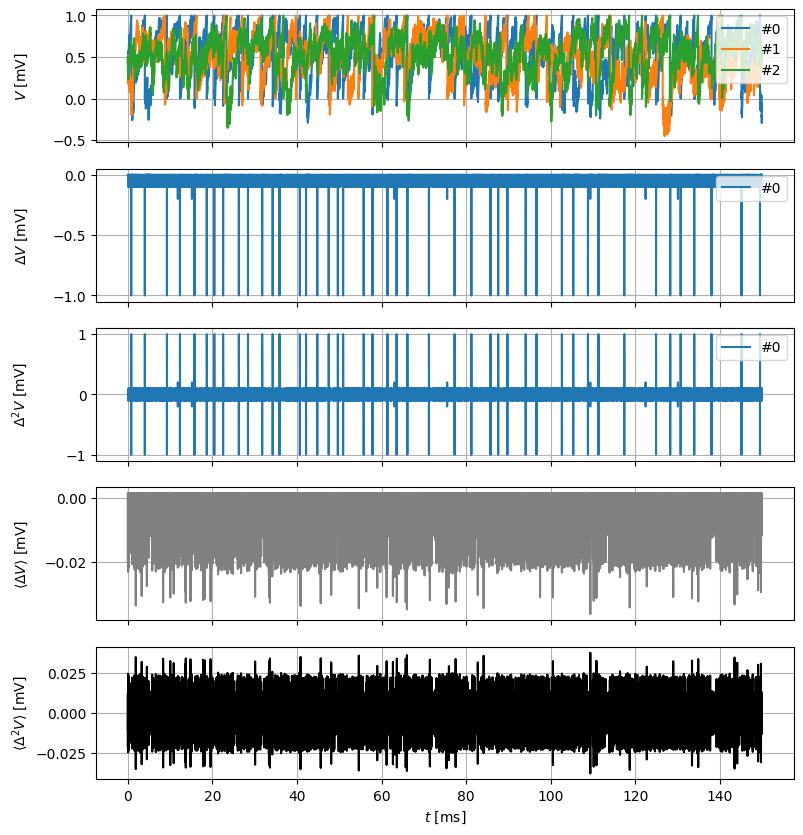

In [121]:
fig, axes = plt.subplots(5, 1, figsize=(9, 10), sharex=True)

ax = axes[0]
ax.plot(Mc.t / ms, Mc.v[0] , c='C0', label='#0')
ax.plot(Mc.t / ms, Mc.v[1], c='C1', label='#1')
ax.plot(Mc.t / ms, Mc.v[2], c='C2', label='#2')
ax.set_ylabel("$V$ [mV]")
ax.grid()
ax.legend(loc='upper right')

ax = axes[1]
ax.plot(Mc.t[:-1] / ms, np.diff(Mc.v[0]), c='C0', label='#0')
ax.set_ylabel(r"$\Delta V$ [mV]")
ax.grid()
ax.legend(loc='upper right')

ax = axes[2]
ax.plot(Mc.t[:-2] / ms, np.diff(Mc.v[0], 2), c='C0', label='#0')
ax.set_ylabel(r"$\Delta^2 V$ [mV]")
ax.grid()
ax.legend(loc='upper right')

ax = axes[3]
ax.plot(Mc.t[:-1] / ms, np.mean(np.diff(Mc.v), axis=0), c='gray')
ax.set_ylabel(r"$\langle\Delta V\rangle$ [mV]")
ax.grid()

ax = axes[4]
ax.plot(Mc.t[:-2] / ms, np.diff(np.mean(Mc.v, axis=0), 2), c='k')
ax.set_ylabel(r"$\langle\Delta^2 V\rangle$ [mV]")
ax.grid()

axes[-1].set_xlabel("$t$ [ms]")
fig.align_ylabels(axes)
plt.show()

(-13.315994726922991+0j)


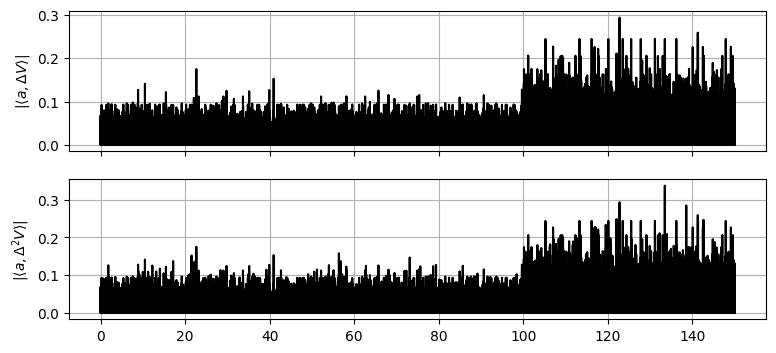

In [122]:
E, EV = np.linalg.eig(W_1.T - W_2.T)
idx = np.argmin(np.real(E))
a = EV[:, idx]
print(E[idx])


# E, EV = np.linalg.eig(W_1.T)
# idx = np.argmin(np.abs(E))
# a = EV[:, idx]
# print(E[idx])

fig, axes = plt.subplots(2, 1, figsize=(9, 4), sharex=True)

ax = axes[0]
ax.plot(Mc.t[:-1] / ms, np.abs(np.dot(a, np.diff(Mc.v, 1))), c='k')
ax.set_ylabel(r"$|\langle a,\Delta V\rangle|$")

ax.grid()

ax = axes[1]
ax.plot(Mc.t[:-2] / ms, np.abs(np.dot(a, np.diff(Mc.v, 2))), c='k')
ax.set_ylabel(r"$|\langle a,\Delta^2 V\rangle|$")
ax.grid()

plt.show()

In [30]:
def lif00():
    # 神经元的个数、稀疏度和平均入度
    N = 1000
    p = 0.1
    K = p * N

    # 模型的方程
    equations = '''
        dv/dt = -v/tau : 1
    '''

    # 膜电位方程的参数
    parameters = {
        'tau': 1.2 * ms,
    }

    # 静息态与放电阈值
    V_rest, V_thres = 0.0, 1.0
    
    # 不同阶段的外界电流和突触电流的参数
    np.random.seed(123)
    W_1 = (np.random.rand(N, N) < p).astype(float)
    W_2 = (np.random.rand(N, N) < p).astype(float)
    stages = [
        # 第一阶段
        {
            'duration': 50.0 * ms,
            'poisson_rate': 1.0 * K / ms,
            'poisson_weight': 0.1 / np.sqrt(K),
            'synapse_weight': -1.0 / np.sqrt(K) * W_1,
        },
        # 第二阶段
        {
            'duration': 50.0 * ms,
            'poisson_rate': 1.0 * K / ms,
            'poisson_weight': 0.1 / np.sqrt(K),
            'synapse_weight': -1.0 / np.sqrt(K) * W_1,
        },
        # 第三阶段
        {
            'duration': 50.0 * ms,
            'poisson_rate': 1.0 * K / ms,
            'poisson_weight': 0.1 / np.sqrt(K),
            'synapse_weight': -1.0 / np.sqrt(K) * W_2,
        },
    ]
    
    # 预处理：找出所有可能相连的边（任一阶段相连即可）
    # 如果找不到，说明每个阶段都是零矩阵，为了简化代码，人为设置 0->0 相连
    # 请注意，这仍然可能导致性能低下，即使每个阶段稀疏连接。
    # 更优化更优雅的方案留待后续探究。
    mat = ((stage["synapse_weight"] != 0) for stage in stages)
    mat = functools.reduce(lambda x, y: x | y, mat)
    row, col = np.nonzero(mat)
    if row.size == 0:
        row, col = [0], [0]
        
    # 使用 brian2 演化模型
    br2.start_scope()
    br2.defaultclock.dt = 0.001 * ms
    
    G = br2.NeuronGroup(
        N=N,
        model=equations,
        namespace=parameters,
        threshold="v > V_thres",
        reset = "v = V_rest",
        method='exponential_euler',
    )
    G.v[:] = np.random.rand(N)
    
    # 定义泊松电流模型（但连接强度在后面模拟时才指定）
    PG = br2.PoissonGroup(N=N, rates=np.zeros(N) / ms)
    PS = br2.Synapses(
        PG, G,
        model='weight : 1',
        on_pre='v += weight',
        namespace=parameters,
    )
    PS.connect(j='i')
    
    # 定义突触电流模型（但连接在后面模拟时才指定）
    WS = br2.Synapses(
        G, G,
        model='weight : 1',
        on_pre='v += weight',
        namespace=parameters,
    )
    WS.connect(i=row, j=col)
    
    # 定义状态记录器（每一步迭代都要进行记录）
    Mc = br2.StateMonitor(G, ['v'], record=True)
    Md = br2.SpikeMonitor(G)
    Mr = br2.PopulationRateMonitor(G)

    # 开始每个阶段的模拟
    for stage in stages:
        # 调整参数
        PG.rates = stage['poisson_rate']
        PS.weight = stage['poisson_weight']
        WS.weight[:] = stage['synapse_weight'][row, col]
        # 进行模拟
        br2.run(stage['duration'], report='text')

        
    return Mc, Md, Mr, W_1, W_2

In [31]:
Mc, Md, Mr, W_1, W_2 = lif00()

Starting simulation at t=0. s for a duration of 50. ms
50. ms (100%) simulated in 2s
Starting simulation at t=50. ms for a duration of 50. ms
50. ms (100%) simulated in 2s
Starting simulation at t=100. ms for a duration of 50. ms
50. ms (100%) simulated in 2s


INFO       width adjusted from 2. ms to 2.001 ms [brian2.monitors.ratemonitor.adjusted_width]


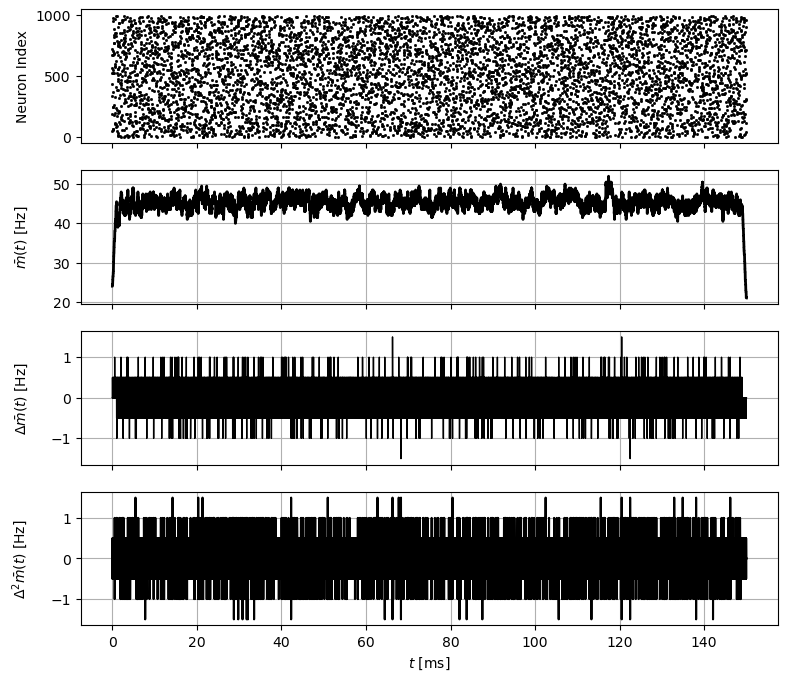

In [32]:
fig, axes = plt.subplots(4, 1, figsize=(9, 8), sharex=True)

Z_SR = Mr.smooth_rate('flat', 2.0 * ms) / Hz

ax = axes[0]
ax.plot(Md.t / ms, Md.i, 'sk', ms=1)
ax.set_ylabel("Neuron Index")

ax = axes[1]
ax.plot(Mr.t / ms, Z_SR, c='k', lw=2)
ax.set_ylabel(r"$\bar{m}(t)$ [Hz]")
ax.grid()

ax = axes[2]
ax.plot(Mr.t[:-1] / ms, np.diff(Z_SR), c='k', lw=1)
ax.set_ylabel(r"$\Delta\bar{m}(t)$ [Hz]")
ax.grid()

ax = axes[3]
ax.plot(Mr.t[:-2] / ms, np.diff(Z_SR, 2), c='k')
ax.set_ylabel(r"$\Delta^2\bar{m}(t)$ [Hz]")
ax.grid()

axes[-1].set_xlabel("$t$ [ms]")
fig.align_ylabels(axes)
plt.show()

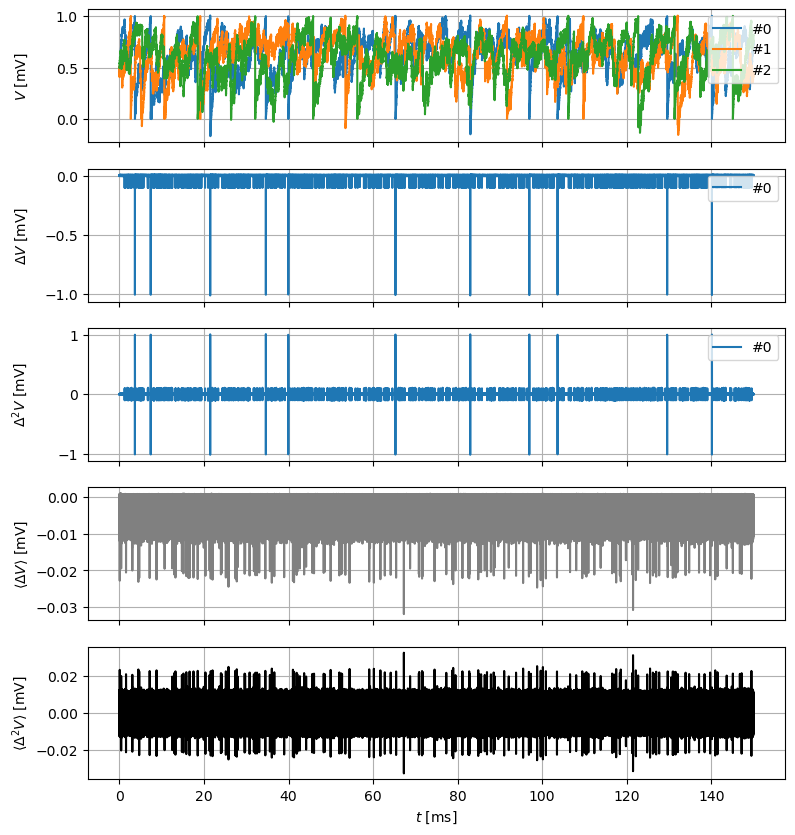

In [33]:
fig, axes = plt.subplots(5, 1, figsize=(9, 10), sharex=True)

ax = axes[0]
ax.plot(Mc.t / ms, Mc.v[0] , c='C0', label='#0')
ax.plot(Mc.t / ms, Mc.v[1], c='C1', label='#1')
ax.plot(Mc.t / ms, Mc.v[2], c='C2', label='#2')
ax.set_ylabel("$V$ [mV]")
ax.grid()
ax.legend(loc='upper right')

ax = axes[1]
ax.plot(Mc.t[:-1] / ms, np.diff(Mc.v[0]), c='C0', label='#0')
ax.set_ylabel(r"$\Delta V$ [mV]")
ax.grid()
ax.legend(loc='upper right')

ax = axes[2]
ax.plot(Mc.t[:-2] / ms, np.diff(Mc.v[0], 2), c='C0', label='#0')
ax.set_ylabel(r"$\Delta^2 V$ [mV]")
ax.grid()
ax.legend(loc='upper right')

ax = axes[3]
ax.plot(Mc.t[:-1] / ms, np.mean(np.diff(Mc.v), axis=0), c='gray')
ax.set_ylabel(r"$\langle\Delta V\rangle$ [mV]")
ax.grid()

ax = axes[4]
ax.plot(Mc.t[:-2] / ms, np.diff(np.mean(Mc.v, axis=0), 2), c='k')
ax.set_ylabel(r"$\langle\Delta^2 V\rangle$ [mV]")
ax.grid()

axes[-1].set_xlabel("$t$ [ms]")
fig.align_ylabels(axes)
plt.show()

(1, 1000)


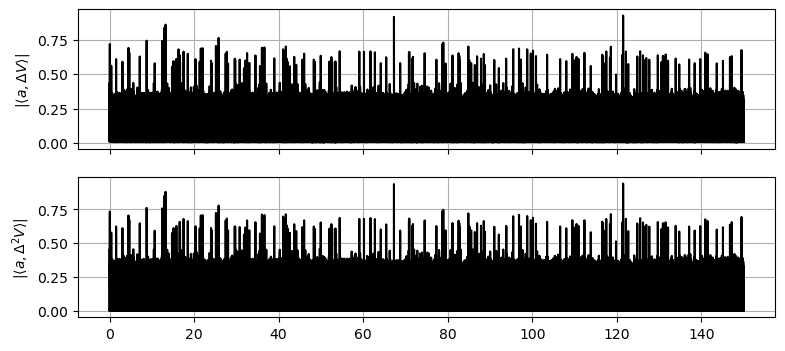

In [44]:
# E, EV = np.linalg.eig(W_1.T - W_2.T)
# idx = np.argmin(np.real(E))
# a = EV[:, idx]
# print(E[idx])

u,s,vt = svds(np.diff(Mc.v[:,12000:14000], 2), k=1, which='LM')
a = u.T.copy()
print(a.shape)
# E, EV = np.linalg.eig(W_1.T)
# idx = np.argmin(np.abs(E))
# a = EV[:, idx]
# print(E[idx])

fig, axes = plt.subplots(2, 1, figsize=(9, 4), sharex=True)

ax = axes[0]
ax.plot(Mc.t[:-1] / ms, np.abs(np.dot(a, np.diff(Mc.v, 1))).flatten(), c='k')
ax.set_ylabel(r"$|\langle a,\Delta V\rangle|$")

ax.grid()

ax = axes[1]
ax.plot(Mc.t[:-2] / ms, np.abs(np.dot(a, np.diff(Mc.v, 2))).flatten(), c='k')
ax.set_ylabel(r"$|\langle a,\Delta^2 V\rangle|$")
ax.grid()

plt.show()

In [39]:
Mc.v.shape

(1000, 150000)

# 分离 HH 中的每一项

In [45]:
def hh00():
    # 模型的方程
    equations = '''
        # 膜电位
        dv/dt  = (- I_Na - I_K - I_L + I_ext + I_syn) / C_m : volt
        I_Na   = g_Na * m**3 * h * (v - E_Na) : amp*metre**-2
        I_K    = g_K  * n**4     * (v - E_K)  : amp*metre**-2
        I_L    = g_L             * (v - E_L)  : amp*metre**-2
    
        # 门控变量
        dm/dt = alpha_m(v) * (1 - m) - beta_m(v) * m : 1
        dn/dt = alpha_n(v) * (1 - n) - beta_n(v) * n : 1
        dh/dt = alpha_h(v) * (1 - h) - beta_h(v) * h : 1
        
        # 外界电流（无效，实际更新在 v 上）
        # 即: I_ext = sum(poisson_weight * delta(t - t_poisson))
        I_ext                                 : amp*metre**-2
        
        # 突触电流（无效，实际更新在 v 上）
        # 即: I_syn = sum(synapse_weight * delta(t - t_spike))
        I_syn                                 : amp*metre**-2
        
        # 额外记录
        v_ext : volt
        v_syn : volt
    '''

    # 膜电位方程的参数
    parameters = {
        'C_m': 1.0 * uF/cm**2,
        'g_L': 0.3 * mS/cm**2,
        'E_L': -54.4 * mV,
        'g_Na': 120.0 * mS/cm**2,
        'E_Na': 50.0 * mV,
        'g_K': 36.0 * mS/cm**2,
        'E_K': -77.0 * mV,
    }

    # 静息态与放电阈值
    V_rest, V_thres = [-65.0, -20.0] * mV

    # 神经元的个数、稀疏度和平均入度
    N = 100
    p = 0.1
    K = p * N

    # 不同阶段的外界电流和突触电流的参数
    np.random.seed(601)
    W_1 = (np.random.rand(N, N) < p).astype(float)
    W_2 = (np.random.rand(N, N) < p).astype(float)
    stages = [
        # 第一阶段
        {
            'duration': 50.0 * ms,
            'poisson_rate': 3.0 * K / ms,
            'poisson_weight': 2.0 / np.sqrt(K) * (uA / cm**2 * ms),
            'synapse_weight': -10.0 / np.sqrt(K) * W_1 * (uA / cm**2 * ms),
        },
        # 第二阶段
        {
            'duration': 50.0 * ms,
            'poisson_rate': 3.0 * K / ms,
            'poisson_weight': 2.0 / np.sqrt(K) * (uA / cm**2 * ms),
            'synapse_weight': -10.0 / np.sqrt(K) * W_1 * (uA / cm**2 * ms),
        },
        # 第三阶段
        {
            'duration': 50.0 * ms,
            'poisson_rate': 3.0 * K / ms,
            'poisson_weight': 2.0 / np.sqrt(K) * (uA / cm**2 * ms),
            'synapse_weight': -10.0 / np.sqrt(K) * W_2 * (uA / cm**2 * ms),
        },
    ]
    
    # 预处理：找出所有可能相连的边（任一阶段相连即可）
    # 如果找不到，说明每个阶段都是零矩阵，为了简化代码，人为设置 0->0 相连
    # 请注意，这仍然可能导致性能低下，即使每个阶段稀疏连接。
    # 更优化更优雅的方案留待后续探究。
    mat = ((stage["synapse_weight"] != 0) for stage in stages)
    mat = functools.reduce(lambda x, y: x | y, mat)
    row, col = np.nonzero(mat)
    if row.size == 0:
        row, col = [0], [0]
        
    # 使用 brian2 演化模型
    br2.start_scope()
    br2.defaultclock.dt = 0.01 * ms
    
    # 定义神经元群体
    G = br2.NeuronGroup(
        N=N,
        model=equations,
        namespace=parameters,
        threshold="v > V_thres",
        refractory="v > V_thres",
        method='exponential_euler',
    )
    
    v0 =  V_rest + np.random.rand(N) * 5.0 * mV
    G.v[:] = v0
    G.m[:] = alpha_m(v0) / (alpha_m(v0) + beta_m(v0))
    G.n[:] = alpha_n(v0) / (alpha_n(v0) + beta_n(v0))
    G.h[:] = alpha_h(v0) / (alpha_h(v0) + beta_h(v0))
    
    # 定义泊松电流模型（但连接强度在后面模拟时才指定）
    PG = br2.PoissonGroup(N=N, rates=np.zeros(N) / ms)
    PS = br2.Synapses(
        PG, G,
        model='weight : amp*metre**-2*second',
        on_pre='''
        v += weight / C_m
        v_ext += weight / C_m
        ''',
        namespace=parameters,
    )
    PS.connect(j='i')
    
    # 定义突触电流模型（但连接在后面模拟时才指定）
    WS = br2.Synapses(
        G, G,
        model='weight : amp*metre**-2*second',
        on_pre='''
        v += weight / C_m
        v_syn += weight / C_m
        ''',
        namespace=parameters,
    )
    WS.connect(i=row, j=col)
    
    # 定义状态记录器（每一步迭代都要进行记录）
    Mc = br2.StateMonitor(G, ['v', 'v_ext', 'v_syn'], record=True)
    Md = br2.SpikeMonitor(G)
    Mr = br2.PopulationRateMonitor(G)
    
    # 开始每个阶段的模拟
    for stage in stages:
        # 调整参数
        PG.rates = stage['poisson_rate']
        PS.weight = stage['poisson_weight']
        WS.weight[:] = stage['synapse_weight'][row, col]
        # 进行模拟
        br2.run(stage['duration'], report='text')
        
    return Mc, Md, Mr, W_1, W_2

In [46]:
Mc, Md, Mr, W_1, W_2 = hh00()

Starting simulation at t=0. s for a duration of 50. ms
27.57 ms (55%) simulated in 10s, estimated 8s remaining.
50. ms (100%) simulated in 18s
Starting simulation at t=50. ms for a duration of 50. ms
27.77 ms (55%) simulated in 10s, estimated 8s remaining.
50. ms (100%) simulated in 17s
Starting simulation at t=100. ms for a duration of 50. ms
27.83 ms (55%) simulated in 10s, estimated 8s remaining.
50. ms (100%) simulated in 17s


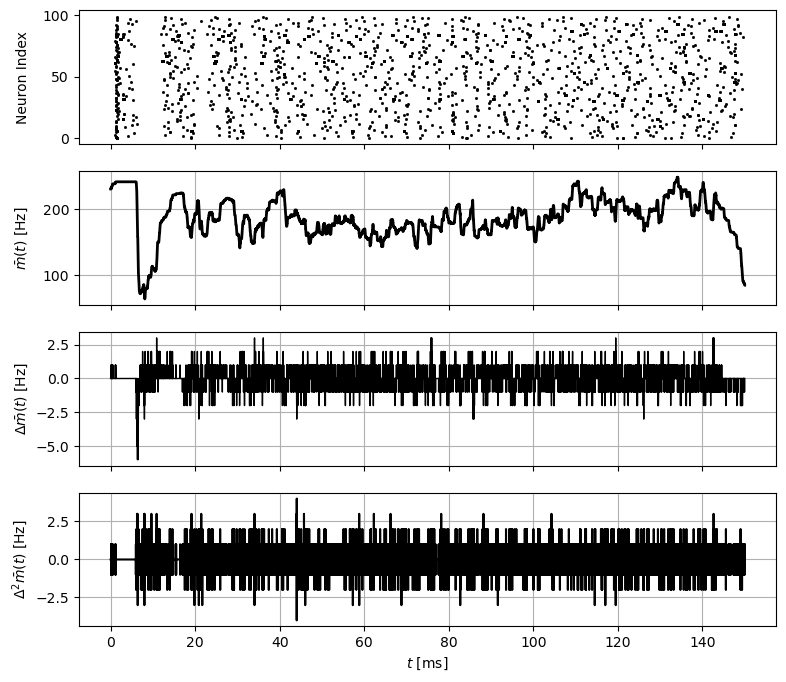

In [47]:
fig, axes = plt.subplots(4, 1, figsize=(9, 8), sharex=True)

Z_SR = Mr.smooth_rate('flat', 10.0 * ms) / Hz

ax = axes[0]
ax.plot(Md.t / ms, Md.i, 'sk', ms=1)
ax.set_ylabel("Neuron Index")

ax = axes[1]
ax.plot(Mr.t / ms, Z_SR, c='k', lw=2)
ax.set_ylabel(r"$\bar{m}(t)$ [Hz]")
ax.grid()

ax = axes[2]
ax.plot(Mr.t[:-1] / ms, np.diff(Z_SR), c='k', lw=1)
ax.set_ylabel(r"$\Delta\bar{m}(t)$ [Hz]")
ax.grid()

ax = axes[3]
ax.plot(Mr.t[:-2] / ms, np.diff(Z_SR, 2), c='k')
ax.set_ylabel(r"$\Delta^2\bar{m}(t)$ [Hz]")
ax.grid()

axes[-1].set_xlabel("$t$ [ms]")
fig.align_ylabels(axes)
plt.show()

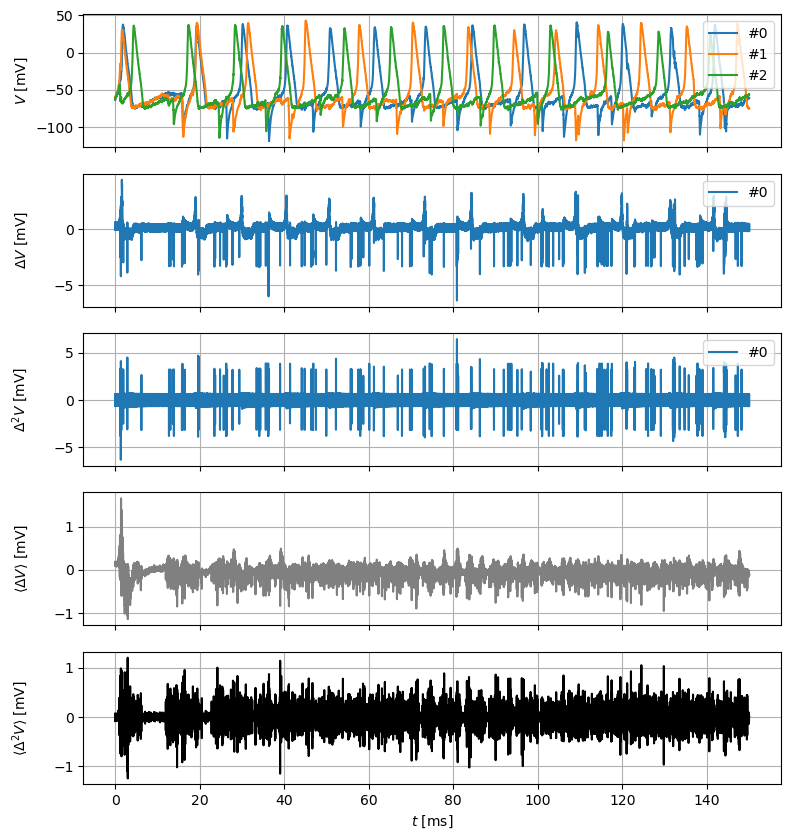

In [48]:
fig, axes = plt.subplots(5, 1, figsize=(9, 10), sharex=True)

ax = axes[0]
ax.plot(Mc.t / ms, Mc.v[0] / mV, c='C0', label='#0')
ax.plot(Mc.t / ms, Mc.v[1] / mV, c='C1', label='#1')
ax.plot(Mc.t / ms, Mc.v[2] / mV, c='C2', label='#2')
ax.set_ylabel("$V$ [mV]")
ax.grid()
ax.legend(loc='upper right')

ax = axes[1]
ax.plot(Mc.t[:-1] / ms, np.diff(Mc.v[0] / mV), c='C0', label='#0')
ax.set_ylabel(r"$\Delta V$ [mV]")
ax.grid()
ax.legend(loc='upper right')

ax = axes[2]
ax.plot(Mc.t[:-2] / ms, np.diff(Mc.v[0] / mV, 2), c='C0', label='#0')
ax.set_ylabel(r"$\Delta^2 V$ [mV]")
ax.grid()
ax.legend(loc='upper right')

ax = axes[3]
ax.plot(Mc.t[:-1] / ms, np.mean(np.diff(Mc.v / mV), axis=0), c='gray')
ax.set_ylabel(r"$\langle\Delta V\rangle$ [mV]")
ax.grid()

ax = axes[4]
ax.plot(Mc.t[:-2] / ms, np.diff(np.mean(Mc.v / mV, axis=0), 2), c='k')
ax.set_ylabel(r"$\langle\Delta^2 V\rangle$ [mV]")
ax.grid()

axes[-1].set_xlabel("$t$ [ms]")
fig.align_ylabels(axes)
plt.show()

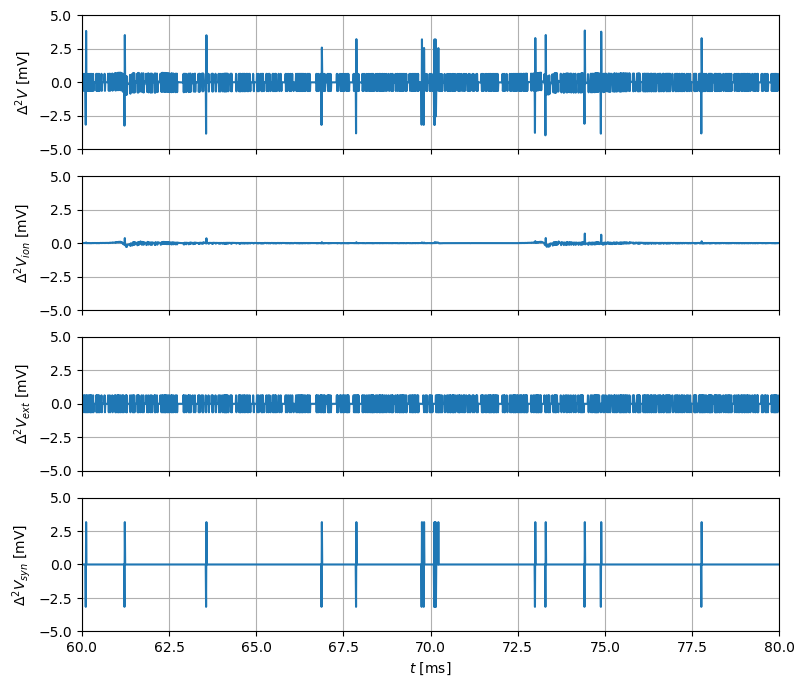

In [49]:
fig, axes = plt.subplots(4, 1, figsize=(9, 8), sharex=True)

ax = axes[0]
ax.plot(Mc.t[:-2] / ms, np.diff(Mc.v[0] / mV, 2), c='C0', label='#0')
ax.set_ylabel(r"$\Delta^2 V$ [mV]")
ax.grid()

ax = axes[1]
ax.plot(Mc.t[:-2] / ms, np.diff((Mc.v[0] - Mc.v_ext[0] - Mc.v_syn[0])/ mV, 2), c='C0', label='#0')
ax.set_ylabel(r"$\Delta^2 V_{ion}$ [mV]")
ax.grid()

ax = axes[2]
ax.plot(Mc.t[:-2] / ms, np.diff(Mc.v_ext[0] / mV, 2), c='C0', label='#0')
ax.set_ylabel(r"$\Delta^2 V_{ext}$ [mV]")
ax.grid()

ax = axes[3]
ax.plot(Mc.t[:-2] / ms, np.diff(Mc.v_syn[0] / mV, 2), c='C0', label='#0')
ax.set_ylabel(r"$\Delta^2 V_{syn}$ [mV]")
ax.grid()


for ax in axes:
    ax.set_ylim(-5, 5)
axes[-1].set_xlabel("$t$ [ms]")
axes[-1].set_xlim(60, 80)
fig.align_ylabels(axes)
plt.show()

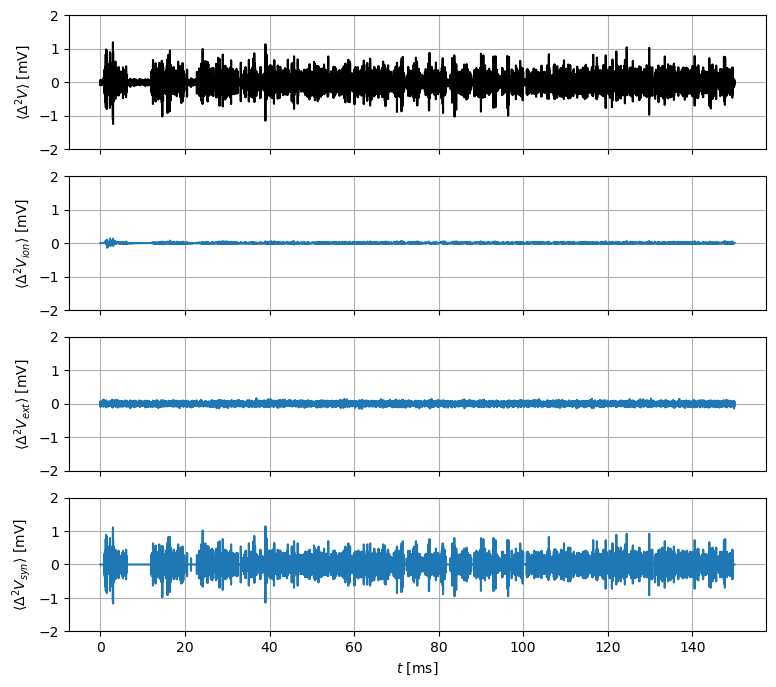

In [50]:
fig, axes = plt.subplots(4, 1, figsize=(9, 8), sharex=True)

ax = axes[0]
ax.plot(Mc.t[:-2] / ms, np.diff(np.mean(Mc.v / mV, axis=0), 2), c='k')
ax.set_ylabel(r"$\langle\Delta^2 V\rangle$ [mV]")
ax.grid()

ax = axes[1]
ax.plot(Mc.t[:-2] / ms, np.diff(np.mean((Mc.v - Mc.v_ext - Mc.v_syn) / mV, axis=0), 2), c='C0', label='#0')
ax.set_ylabel(r"$\langle\Delta^2 V_{ion}\rangle$ [mV]")
ax.grid()

ax = axes[2]
ax.plot(Mc.t[:-2] / ms, np.diff(np.mean(Mc.v_ext / mV, axis=0), 2), c='C0', label='#0')
ax.set_ylabel(r"$\langle\Delta^2 V_{ext}\rangle$ [mV]")
ax.grid()

ax = axes[3]
ax.plot(Mc.t[:-2] / ms, np.diff(np.mean(Mc.v_syn / mV, axis=0), 2), c='C0', label='#0')
ax.set_ylabel(r"$\langle\Delta^2 V_{syn}\rangle$ [mV]")
ax.grid()


for ax in axes:
    ax.set_ylim(-2, 2)
axes[-1].set_xlabel("$t$ [ms]")
# axes[-1].set_xlim(60, 80)
fig.align_ylabels(axes)
plt.show()

(4.227783184715575+0j)


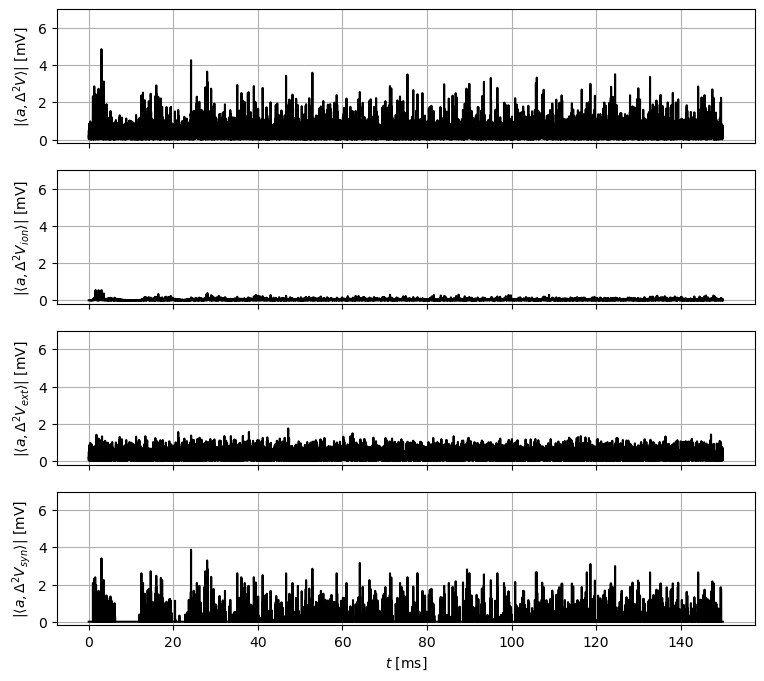

In [51]:
E, EV = np.linalg.eig(W_1 - W_2)
idx = np.argmax(np.real(E))
a = EV[:, idx]
print(E[idx])

# E, EV = np.linalg.eig(W_1)
# idx = np.argmin(np.abs(E))
# a = EV[:, idx]
# print(E[idx])


fig, axes = plt.subplots(4, 1, figsize=(9, 8), sharex=True)

ax = axes[0]
ax.plot(Mc.t[:-2] / ms, np.abs(np.dot(a, np.diff(Mc.v / mV, 2))), c='k')
ax.set_ylabel(r"$|\langle a,\Delta^2 V\rangle|$ [mV]")
ax.grid()

ax = axes[1]
ax.plot(Mc.t[:-2] / ms, np.abs(np.dot(a, np.diff((Mc.v - Mc.v_ext - Mc.v_syn) / mV, 2))), c='k')
ax.set_ylabel(r"$|\langle a,\Delta^2 V_{ion}\rangle|$ [mV]")
ax.grid()

ax = axes[2]
ax.plot(Mc.t[:-2] / ms, np.abs(np.dot(a, np.diff(Mc.v_ext / mV, 2))), c='k')
ax.set_ylabel(r"$|\langle a,\Delta^2 V_{ext}\rangle|$ [mV]")
ax.grid()

ax = axes[3]
ax.plot(Mc.t[:-2] / ms, np.abs(np.dot(a, np.diff(Mc.v_syn / mV, 2))), c='k')
ax.set_ylabel(r"$|\langle a,\Delta^2 V_{syn}\rangle|$ [mV]")
ax.grid()

for ax in axes:
    ax.set_ylim(-0.2, 7)
axes[-1].set_xlabel("$t$ [ms]")
plt.show()

In [52]:
SP = np.zeros(Mc.v.shape)

for t, i in zip(Md.t, Md.i):
    SP[i, int(np.floor(t / (0.01 * ms)))] = 1.0

In [55]:
print(s[-1])

15.920974670390443


In [61]:
Mc.v.shape

(100, 15000)

In [64]:
u,s, vt = svds(np.diff(Mc.v/mV, 2, axis=1)[:, 12000:14000], k=1, which='SM')
print(s)
a = u.flatten()

[15.92097467]


In [63]:
u,s, vt = np.linalg.svd(np.diff(Mc.v/mV, 2, axis=1)[:, 12000:14000])
print(s[0], s[-1])
# a = u.flatten()

81.66662814614854 15.920974670390441


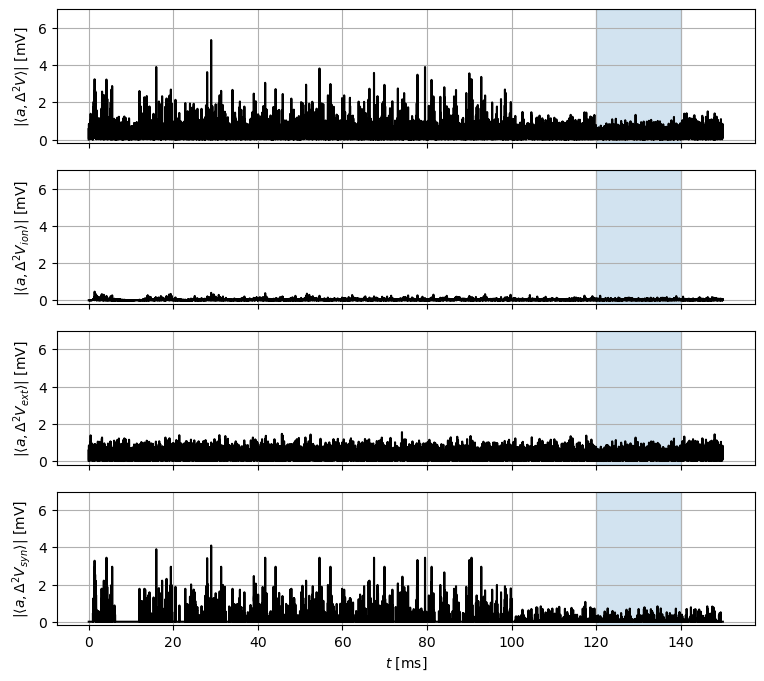

In [65]:
# Z = np.diff(Mc.v / mV, 2)[:, 12000:14000].T
# u, s, vh = np.linalg.svd(Z)
# a = vh[-1]
# print(s[-1])

fig, axes = plt.subplots(4, 1, figsize=(9, 8), sharex=True)

ax = axes[0]
ax.plot(Mc.t[:-2] / ms, np.abs(np.dot(a, np.diff(Mc.v / mV, 2))), c='k')
ax.set_ylabel(r"$|\langle a,\Delta^2 V\rangle|$ [mV]")
ax.grid()

ax = axes[1]
ax.plot(Mc.t[:-2] / ms, np.abs(np.dot(a, np.diff((Mc.v - Mc.v_ext - Mc.v_syn) / mV, 2))), c='k')
ax.set_ylabel(r"$|\langle a,\Delta^2 V_{ion}\rangle|$ [mV]")
ax.grid()

ax = axes[2]
ax.plot(Mc.t[:-2] / ms, np.abs(np.dot(a, np.diff(Mc.v_ext / mV, 2))), c='k')
ax.set_ylabel(r"$|\langle a,\Delta^2 V_{ext}\rangle|$ [mV]")
ax.grid()

ax = axes[3]
ax.plot(Mc.t[:-2] / ms, np.abs(np.dot(a, np.diff(Mc.v_syn / mV, 2))), c='k')
ax.set_ylabel(r"$|\langle a,\Delta^2 V_{syn}\rangle|$ [mV]")
ax.grid()

for ax in axes:
    ax.set_ylim(-0.2, 7)
    ax.fill_between([120,140],-0.2, 7, alpha=0.2,color="C0")
axes[-1].set_xlabel("$t$ [ms]")
plt.show()